# ReorderPoint — EDA (Track A, HOBBIES subset)

Exploring seasonality, intermittency, and price effects in the M5 HOBBIES-category panel (all stores/states), produced by `reorderpoint.ingest.load_track_a`. Findings here motivate the modelling ladder in Phase 2+ and are exported to `reports/eda.md`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().parent
panel = pd.read_parquet(REPO_ROOT / 'data' / 'track_a' / 'processed' / 'panel.parquet')
panel['date'] = pd.to_datetime(panel['date'])
panel.head()

Matplotlib is building the font cache; this may take a moment.


,series_id,date,y,price,item_id,dept_id,cat_id,store_id,state_id,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap
0,HOBBIES_1_001_CA_1_validation,2011-01-29,0,NaN,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,1,2011,NaN,NaN,NaN,NaN,0
1,HOBBIES_1_001_CA_1_validation,2011-01-30,0,NaN,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,2,1,2011,NaN,NaN,NaN,NaN,0
2,HOBBIES_1_001_CA_1_validation,2011-01-31,0,NaN,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,3,1,2011,NaN,NaN,NaN,NaN,0
3,HOBBIES_1_001_CA_1_validation,2011-02-01,0,NaN,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,4,2,2011,NaN,NaN,NaN,NaN,1
4,HOBBIES_1_001_CA_1_validation,2011-02-02,0,NaN,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,5,2,2011,NaN,NaN,NaN,NaN,1


## Overview

In [2]:
n_series = panel['series_id'].nunique()
n_rows = len(panel)
date_min, date_max = panel['date'].min(), panel['date'].max()
n_stores = panel['store_id'].nunique()
n_states = panel['state_id'].nunique()
n_depts = panel['dept_id'].nunique()

print(f'Rows: {n_rows:,}')
print(f'Series: {n_series:,}')
print(f'Stores: {n_stores}, States: {n_states}, Depts: {n_depts}')
print(f'Date range: {date_min.date()} .. {date_max.date()} '
      f'({(date_max - date_min).days} days)')

Rows: 10,808,450
Series: 5,650
Stores: 10, States: 3, Depts: 2
Date range: 2011-01-29 .. 2016-04-24 (1912 days)


## Seasonality

Total units sold aggregated by calendar month (all years pooled) and by day of week.

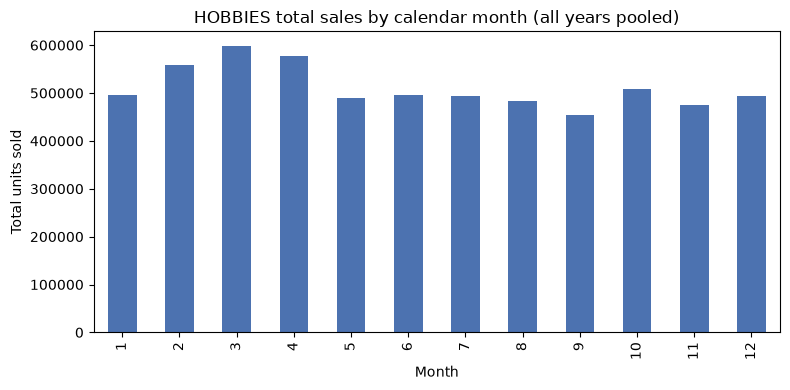

Peak month: 3 (9.8% of annual units)
Trough month: 9 (7.4% of annual units)
Peak/trough ratio: 1.32x


In [3]:
monthly = panel.groupby('month')['y'].sum()
monthly_share = (monthly / monthly.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
monthly.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_xlabel('Month')
ax.set_ylabel('Total units sold')
ax.set_title('HOBBIES total sales by calendar month (all years pooled)')
plt.tight_layout()
plt.show()

peak_month = int(monthly.idxmax())
trough_month = int(monthly.idxmin())
seasonality_ratio = monthly.max() / monthly.min()
print(f'Peak month: {peak_month} ({monthly_share[peak_month]}% of annual units)')
print(f'Trough month: {trough_month} ({monthly_share[trough_month]}% of annual units)')
print(f'Peak/trough ratio: {seasonality_ratio:.2f}x')

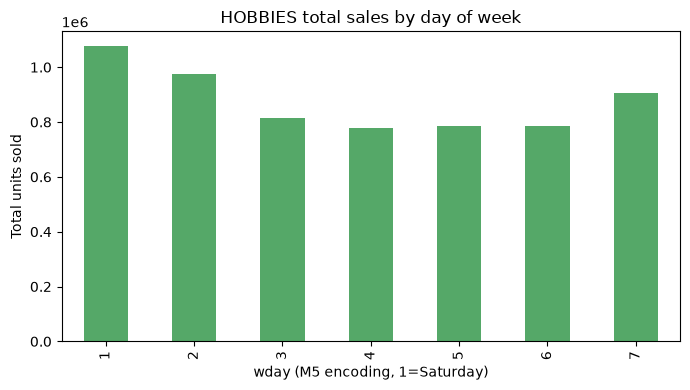

Highest-volume wday: 1 (17.6% of weekly units)
Lowest-volume wday: 4 (12.7% of weekly units)
Peak/trough ratio across weekdays: 1.38x


In [4]:
wday_totals = panel.groupby('wday')['y'].sum()
wday_share = (wday_totals / wday_totals.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
wday_totals.plot(kind='bar', ax=ax, color='#55A868')
ax.set_xlabel('wday (M5 encoding, 1=Saturday)')
ax.set_ylabel('Total units sold')
ax.set_title('HOBBIES total sales by day of week')
plt.tight_layout()
plt.show()

weekday_peak = int(wday_totals.idxmax())
weekday_trough = int(wday_totals.idxmin())
weekday_ratio = wday_totals.max() / wday_totals.min()
print(f'Highest-volume wday: {weekday_peak} ({wday_share[weekday_peak]}% of weekly units)')
print(f'Lowest-volume wday: {weekday_trough} ({wday_share[weekday_trough]}% of weekly units)')
print(f'Peak/trough ratio across weekdays: {weekday_ratio:.2f}x')

## Intermittency

What fraction of series-days have zero sales, and how many series are dominated by zeros? This directly motivates using Tweedie loss / zero-inflated handling in the LightGBM model (Phase 3) rather than assuming continuous demand.

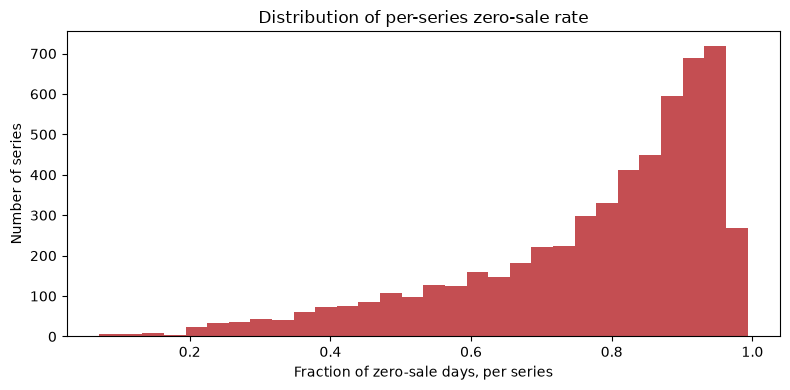

Overall zero-sale day rate: 77.3%
Median per-series zero-sale rate: 83.2%
Series with >50% zero-sale days: 89.4%


In [5]:
overall_zero_rate = (panel['y'] == 0).mean()

series_zero_rate = panel.groupby('series_id')['y'].apply(lambda s: (s == 0).mean())

fig, ax = plt.subplots(figsize=(8, 4))
series_zero_rate.plot(kind='hist', bins=30, ax=ax, color='#C44E52')
ax.set_xlabel('Fraction of zero-sale days, per series')
ax.set_ylabel('Number of series')
ax.set_title('Distribution of per-series zero-sale rate')
plt.tight_layout()
plt.show()

highly_intermittent = (series_zero_rate > 0.5).mean()
median_zero_rate = series_zero_rate.median()
print(f'Overall zero-sale day rate: {overall_zero_rate:.1%}')
print(f'Median per-series zero-sale rate: {median_zero_rate:.1%}')
print(f'Series with >50% zero-sale days: {highly_intermittent:.1%}')

## Price effects

Within each series, does a price change coincide with a sales change? Using each series' own mean as baseline (fixed-effect-style), correlate the price deviation against the sales deviation, restricted to series that actually have price variation.

Series with any price variation: 3,761 / 5,650


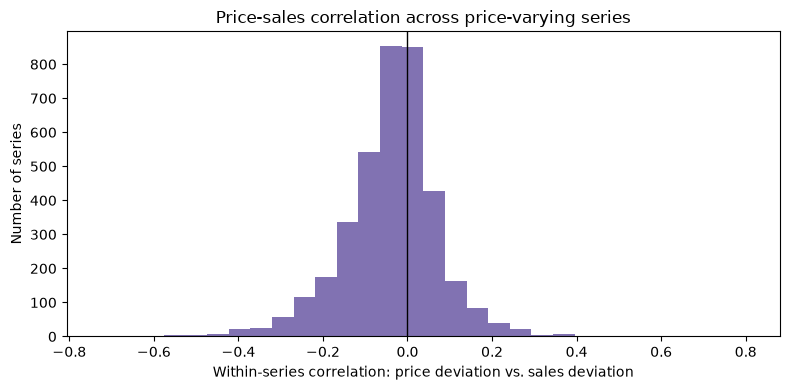

Series analysed: 3,761
Median price/sales correlation: -0.028
Share with negative correlation (expected sign): 64.5%


In [6]:
priced = panel.dropna(subset=['price']).copy()
price_variation = priced.groupby('series_id')['price'].nunique()
varying_series = price_variation[price_variation > 1].index
print(f'Series with any price variation: {len(varying_series):,} / {price_variation.shape[0]:,}')

sub = priced[priced['series_id'].isin(varying_series)].copy()
sub['price_dev'] = sub.groupby('series_id')['price'].transform(lambda s: s - s.mean())
sub['y_dev'] = sub.groupby('series_id')['y'].transform(lambda s: s - s.mean())

def _corr(g):
    if g['price_dev'].std() == 0 or g['y_dev'].std() == 0:
        return np.nan
    return g['price_dev'].corr(g['y_dev'])

series_corr = sub.groupby('series_id').apply(_corr).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
series_corr.plot(kind='hist', bins=30, ax=ax, color='#8172B2')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Within-series correlation: price deviation vs. sales deviation')
ax.set_ylabel('Number of series')
ax.set_title('Price-sales correlation across price-varying series')
plt.tight_layout()
plt.show()

pct_negative = (series_corr < 0).mean()
median_corr = series_corr.median()
print(f'Series analysed: {len(series_corr):,}')
print(f'Median price/sales correlation: {median_corr:.3f}')
print(f'Share with negative correlation (expected sign): {pct_negative:.1%}')

## SNAP effect (bonus)

M5's SNAP flag marks days SNAP (food-assistance) benefits are usable in that state. Checking whether it shows up in HOBBIES sales too (it's not a food category, so this is a sanity/curiosity check, not an expected strong driver).

In [7]:
snap_means = panel.groupby('snap')['y'].mean()
snap_lift = snap_means.get(1, np.nan) / snap_means.get(0, np.nan)
print(f'Mean units/day, non-SNAP days: {snap_means.get(0, float("nan")):.3f}')
print(f'Mean units/day, SNAP days: {snap_means.get(1, float("nan")):.3f}')
print(f'SNAP-day lift: {snap_lift:.2f}x')

Mean units/day, non-SNAP days: 0.562
Mean units/day, SNAP days: 0.576
SNAP-day lift: 1.02x


## Where this data could break a naive model

In [8]:
first_sale = panel[panel['y'] > 0].groupby('series_id')['date'].min()
late_starters = (first_sale > (panel['date'].min() + pd.Timedelta(days=90))).sum()
print(f'Series with first nonzero sale >90 days after the panel start '
      f'(likely new items mid-window): {late_starters:,} / {n_series:,}')

top5 = panel.groupby('series_id')['y'].sum().sort_values(ascending=False).head(5)
print('\nTop 5 series by total units sold:')
print(top5)

Series with first nonzero sale >90 days after the panel start (likely new items mid-window): 3,056 / 5,650



Top 5 series by total units sold:
series_id
HOBBIES_1_234_CA_3_validation    29742
HOBBIES_1_348_CA_1_validation    22744
HOBBIES_1_371_CA_1_validation    22595
HOBBIES_1_254_CA_3_validation    20996
HOBBIES_1_371_CA_3_validation    19812
Name: y, dtype: int64


In [9]:
display(Markdown(f'''
## Summary

- **Panel:** {n_rows:,} rows, {n_series:,} series (HOBBIES category, all {n_stores} stores / {n_states} states), {date_min.date()} to {date_max.date()}.
- **Seasonality:** month {peak_month} is the highest-volume month ({monthly_share[peak_month]}% of annual units), month {trough_month} the lowest ({monthly_share[trough_month]}%) — a {seasonality_ratio:.2f}x peak/trough ratio. Day-of-week effect: wday {weekday_peak} vs {weekday_trough}, {weekday_ratio:.2f}x peak/trough.
- **Intermittency:** {overall_zero_rate:.1%} of all series-days have zero sales; median per-series zero rate is {median_zero_rate:.1%}; {highly_intermittent:.1%} of series are zero on more than half their days. This is a real zero-inflated-demand problem, not an edge case — confirms Tweedie/zero-inflated loss is warranted for the Phase 3 LightGBM model, not plain L2.
- **Price effects:** {len(varying_series):,} of {price_variation.shape[0]:,} series show any price variation at all. Among those, median within-series price/sales correlation is {median_corr:.3f}, with {pct_negative:.1%} of series showing the expected negative sign (price up, sales down) — a real but noisy signal, worth including as a feature rather than relied on alone.
- **SNAP:** {snap_lift:.2f}x sales lift on SNAP-eligible days for this (non-food) category — a weak/incidental effect as expected, kept as a feature for completeness rather than a primary driver.
- **New items:** {late_starters:,} series have their first nonzero sale more than 90 days into the panel — genuine new-item cold-start cases the model needs to handle, not just steady-state series.
'''))


## Summary

- **Panel:** 10,808,450 rows, 5,650 series (HOBBIES category, all 10 stores / 3 states), 2011-01-29 to 2016-04-24.
- **Seasonality:** month 3 is the highest-volume month (9.8% of annual units), month 9 the lowest (7.4%) — a 1.32x peak/trough ratio. Day-of-week effect: wday 1 vs 4, 1.38x peak/trough.
- **Intermittency:** 77.3% of all series-days have zero sales; median per-series zero rate is 83.2%; 89.4% of series are zero on more than half their days. This is a real zero-inflated-demand problem, not an edge case — confirms Tweedie/zero-inflated loss is warranted for the Phase 3 LightGBM model, not plain L2.
- **Price effects:** 3,761 of 5,650 series show any price variation at all. Among those, median within-series price/sales correlation is -0.028, with 64.5% of series showing the expected negative sign (price up, sales down) — a real but noisy signal, worth including as a feature rather than relied on alone.
- **SNAP:** 1.02x sales lift on SNAP-eligible days for this (non-food) category — a weak/incidental effect as expected, kept as a feature for completeness rather than a primary driver.
- **New items:** 3,056 series have their first nonzero sale more than 90 days into the panel — genuine new-item cold-start cases the model needs to handle, not just steady-state series.
